# Sentiment Analysis using IMDB movie review dataset with NLP & ML

## Problem Statement
The increasing amount of user-generated textual data on digital platforms has created a need for automated systems that can understand human opinions and emotions. Traditional manual analysis of reviews is inefficient and prone to errors. The objective of this project is to build an NLP-based sentiment classification model that preprocesses textual data, extracts meaningful features using TF-IDF, and classifies sentiments using machine learning algorithms such as Logistic Regression.


## Objective of the Project
- To preprocess textual data using NLP techniques.
- To convert text into numerical representations using TF-IDF.
- To train a machine learning model for sentiment classification.
- To evaluate the model using accuracy, precision, recall, F1-score, and confusion matrix.
- To automatically predict the sentiment of unseen reviews.

## Imports

In [3]:
# Data handling
import numpy as np
import pandas as pd
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Regular Expression - Text Cleaning
import re
import string
# Natural language Toolkit (NLTK)
import nltk
from nltk.tokenize import word_tokenize # tokenization
from nltk.corpus import stopwords # remove stopwords
from nltk.stem import WordNetLemmatizer # Lemmatization (meaningful-dictionary words)
# Dataset splitting
from sklearn.model_selection import train_test_split
# Feature Extraction 
# TF-IDF -> calculates the vector to know importance of the particular word
from sklearn.feature_extraction.text import TfidfVectorizer 
# Models
from sklearn.linear_model import LogisticRegression #Logistic regression
from sklearn.naive_bayes import MultinomialNB # Naive-Bayes 
from sklearn.svm import SVC # SVM
# Evaluation Metrics
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)
# Word Cloud
from wordcloud import WordCloud

## Dataset Loading

In [4]:
data = pd.read_csv(r"C:\Users\Nandana\OneDrive\Desktop\Strydo_internship\DATASET\IMDB Dataset.csv")

## Data Understanding

In [5]:
data.shape

(50000, 2)

In [6]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [8]:
data.isnull().sum()

review       0
sentiment    0
dtype: int64

In [9]:
data.duplicated().sum()

418

In [10]:
data.drop_duplicates(inplace=True)

In [11]:
# Class distribution
data['sentiment'].value_counts()

sentiment
positive    24884
negative    24698
Name: count, dtype: int64

In [12]:
data['sentiment'].value_counts(normalize=True)*100

sentiment
positive    50.187568
negative    49.812432
Name: proportion, dtype: float64

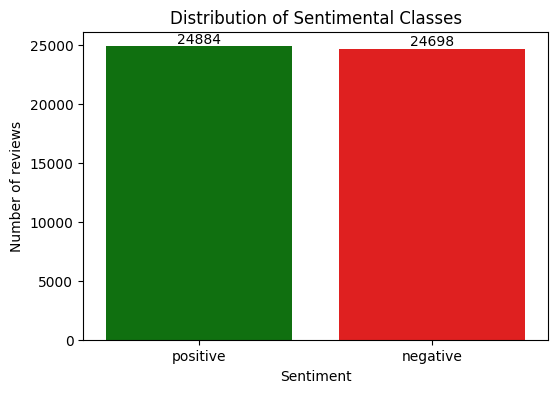

In [13]:
# Class distribution Visualization
plt.figure(figsize=(6,4))
cd=sns.countplot(x='sentiment',
              data=data,
              hue='sentiment',
              palette={'positive':'green',
                       'negative':'red'},
              legend=False)
for container in cd.containers:
    cd.bar_label(container)

plt.title("Distribution of Sentimental Classes")
plt.xlabel("Sentiment")
plt.ylabel("Number of reviews")
plt.show()

In [14]:
# Review length analysis
data['word_count']=data['review'].apply(lambda x: len(str(x).split()))
data['word_count'].describe()

count    49582.000000
mean       231.350167
std        171.542020
min          4.000000
25%        126.000000
50%        173.000000
75%        281.000000
max       2470.000000
Name: word_count, dtype: float64

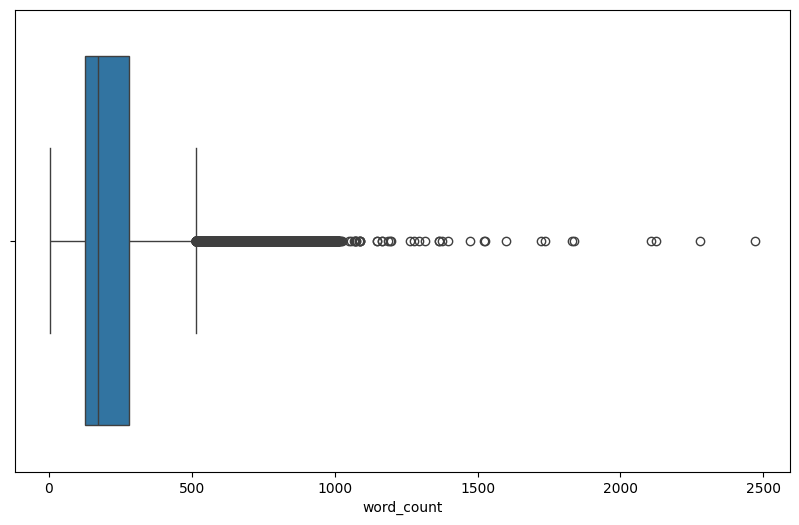

In [15]:
plt.figure(figsize=(10,6))
sns.boxplot(x=data['word_count'])
plt.show()

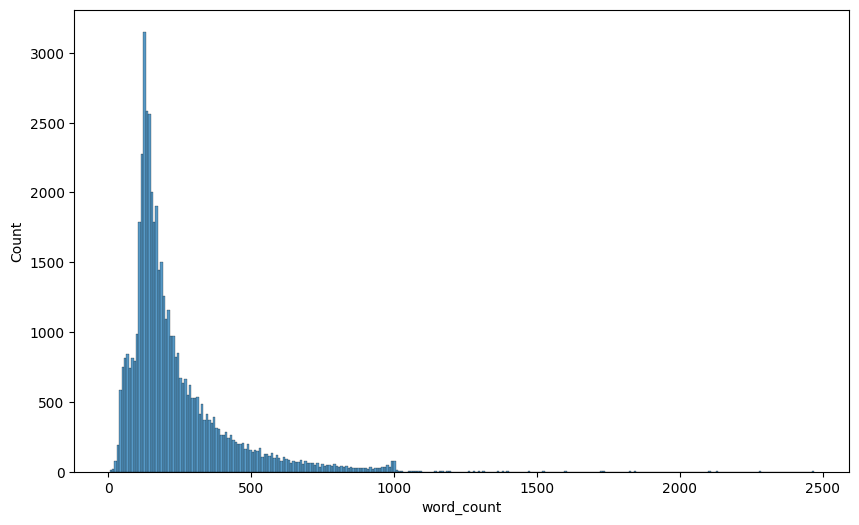

In [16]:
# Visualization
plt.figure(figsize=(10,6))
rl = sns.histplot(data['word_count'])
plt.show()

In [17]:
# Vocabulary Size
len(set(" ".join(data['review']).split()))

438729

## Text Cleaning

In [18]:
def clean_text(text):
    text = str(text).lower()  # Lowercase 
    text = re.sub(r'<.*?>','',text)   # HTML
    text = re.sub(r'http\S+|www\S+','',text)   #URL
    text = re.sub(r'\d+','',text)    # Special Characters
    text = text.translate(str.maketrans('', '',string.punctuation))   #Punctuation
    text = re.sub(r'[^a-zA-Z\s]','',text)  # Numbers
    text = text.encode('ascii','ignore').decode('ascii') # emoji
    text = " ".join(text.split()) # Extra Space
    text = text.replace("not bad", "good")
    text = text.replace("not terrible", "good")
    text = text.replace("not awful", "good")
    text = text.replace("not good", "bad")
    text = text.replace("not enjoyable", "bad")
    return text

In [19]:
data['clean_review'] = data['review'].apply(clean_text)

## Text preprocessing


In [20]:
# Imports
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Nandana\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Nandana\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Nandana\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## 1. Tokenization

In [21]:
data['tokens'] = data['clean_review'].apply(word_tokenize)

## 2. Stop words

In [22]:
stop_words = set(stopwords.words('english'))

negations = {
    'not',
    'no',
    'nor',
    'never',
    "don't",
    "didn't",
    "won't",
    "isn't",
    "wasn't",
    "aren't"
}

stop_words = stop_words - negations

In [23]:
data['tokens'] = data['tokens'].apply(
    lambda x: [word for word in x if word not in stop_words]
)

## 3. Lemmatization

In [24]:
lemmatizer = WordNetLemmatizer()

In [25]:
data['tokens'] = data['tokens'].apply(
    lambda x: [lemmatizer.lemmatize(word, pos='v') for word in x]
)

## 4. Processing Tokens

In [26]:
data['processed_review'] = data['tokens'].apply(
    lambda x: " ".join(x)
)

## Feature Extraction : TF-IDF

In [27]:
# Create Vectorizer
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,3),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

# Transform Text
X = tfidf.fit_transform(data['processed_review'])

# Target Variable
y = data['sentiment']

## Train-Test Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Train model
## 1.Logistic regression

In [29]:
lr = LogisticRegression(
    C=2,
    solver='liblinear',
    max_iter=3000
)
lr.fit(X_train, y_train)

LogisticRegression(C=2, max_iter=3000, solver='liblinear')

## LR Predictions

In [30]:
y_pred_lr = lr.predict(X_test)

## LR Evaluation

In [31]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))


Accuracy: 0.9010789553292327


In [32]:
print("Precision :",precision_score(y_test, y_pred_lr, pos_label= 'positive'))

Precision : 0.8917859243285631


In [33]:
print("Recall :",recall_score(y_test, y_pred_lr, pos_label='positive'))

Recall : 0.913820811570912


In [34]:
print("F1-score :",f1_score(y_test, y_pred_lr, pos_label='positive'))

F1-score : 0.9026689155670206


In [35]:
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

    negative       0.91      0.89      0.90      4939
    positive       0.89      0.91      0.90      4978

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



## LR Confusion matrix

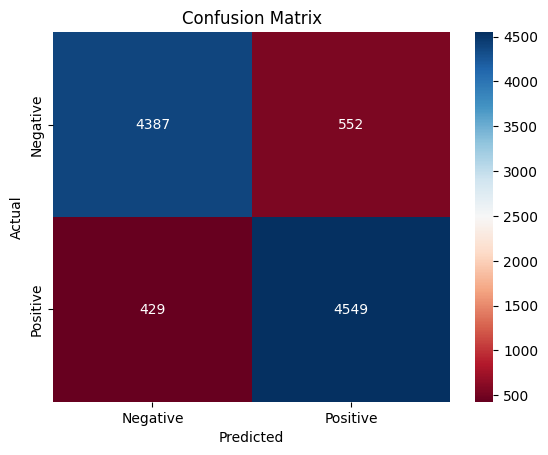

In [36]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(
    cm,
    annot=True,
    fmt='g',
    cmap='RdBu',
    xticklabels=['Negative','Positive'],
    yticklabels=['Negative','Positive']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 2.Naive Bayes 

In [37]:
nb = MultinomialNB()
nb.fit(X_train, y_train)

MultinomialNB()

## NB Predictions

In [38]:
y_pred_nb = nb.predict(X_test)

## NB Evaluation

In [39]:
print("Accuracy:", accuracy_score(y_test, y_pred_nb))

Accuracy: 0.8732479580518302


In [40]:
print("Precision :",precision_score(y_test, y_pred_nb, pos_label= 'positive'))

Precision : 0.8592392353736242


In [41]:
print("Recall :",recall_score(y_test, y_pred_nb, pos_label='positive'))

Recall : 0.8939333065488148


In [42]:
print("F1-score :",f1_score(y_test, y_pred_nb, pos_label='positive'))

F1-score : 0.8762429851334055


In [43]:
print(
    classification_report(
        y_test,
        y_pred_nb
    )
)

              precision    recall  f1-score   support

    negative       0.89      0.85      0.87      4939
    positive       0.86      0.89      0.88      4978

    accuracy                           0.87      9917
   macro avg       0.87      0.87      0.87      9917
weighted avg       0.87      0.87      0.87      9917



## NB Confusion matrix

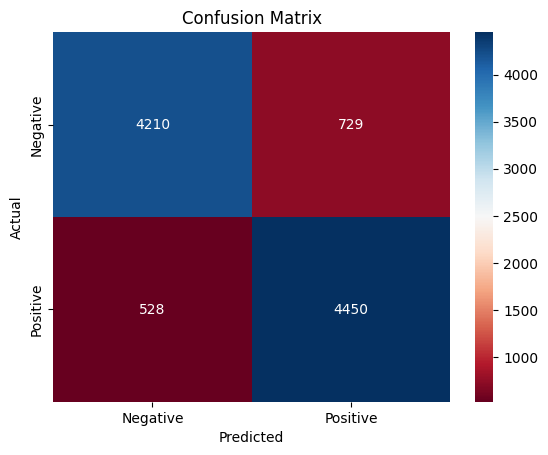

In [44]:
cm = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(
    cm,
    annot=True,
    fmt='g',
    cmap='RdBu',
    xticklabels=['Negative','Positive'],
    yticklabels=['Negative','Positive']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 3. SVC

In [45]:
from sklearn.svm import LinearSVC

svc = LinearSVC(
    random_state=42
)

svc.fit(X_train, y_train)

LinearSVC(random_state=42)

## SVC Prediction

In [46]:
y_pred_svc = svc.predict(X_test)

## SVC Evaluation

In [47]:
print("Accuracy:", accuracy_score(y_test, y_pred_svc))

Accuracy: 0.8931128365433094


In [48]:
print("Precision :",precision_score(y_test, y_pred_svc, pos_label= 'positive'))

Precision : 0.887001185302252


In [49]:
print("Recall :",recall_score(y_test, y_pred_svc, pos_label='positive'))

Recall : 0.9019686621132985


In [50]:
print("F1-score :",f1_score(y_test, y_pred_svc, pos_label='positive'))

F1-score : 0.8944223107569721


In [51]:
print(
    classification_report(
        y_test,
        y_pred_svc
    )
)

              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      4939
    positive       0.89      0.90      0.89      4978

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



## SVC Confusion matrix

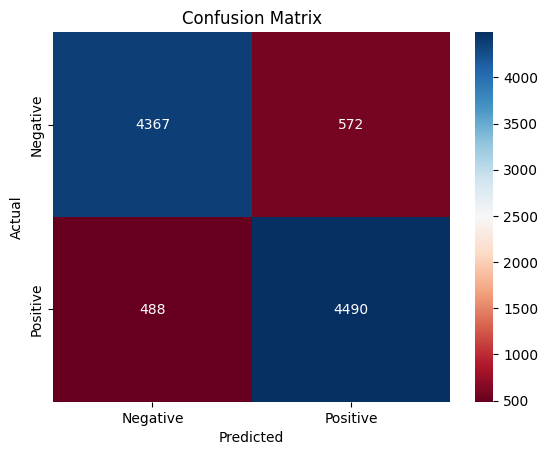

In [52]:
cm = confusion_matrix(y_test, y_pred_svc)

sns.heatmap(
    cm,
    annot=True,
    fmt='g',
    cmap='RdBu',
    xticklabels=['Negative','Positive'],
    yticklabels=['Negative','Positive']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Comparison Table

In [53]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Naive Bayes',
        'SVC'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svc)
    ],

    'Precision': [
        precision_score(y_test,
                        y_pred_lr,
                        pos_label='positive'),
        precision_score(y_test,
                        y_pred_nb,
                        pos_label='positive'),
        precision_score(y_test,
                        y_pred_svc,
                        pos_label='positive')
    ],

    'Recall': [
        recall_score(y_test,
                     y_pred_lr,
                     pos_label='positive'),
        recall_score(y_test,
                     y_pred_nb,
                     pos_label='positive'),
        recall_score(y_test,
                     y_pred_svc,
                     pos_label='positive')
    ],

    'F1 Score': [
        f1_score(y_test,
                 y_pred_lr,
                 pos_label='positive'),
        f1_score(y_test,
                 y_pred_nb,
                 pos_label='positive'),
        f1_score(y_test,
                 y_pred_svc,
                 pos_label='positive')
    ]
})

results.sort_values(
    by='Accuracy',
    ascending=False
)
results = results.round(4)
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9011,0.8918,0.9138,0.9027
1,Naive Bayes,0.8732,0.8592,0.8939,0.8762
2,SVC,0.8931,0.8870,0.9020,0.8944


### Comparison visualization

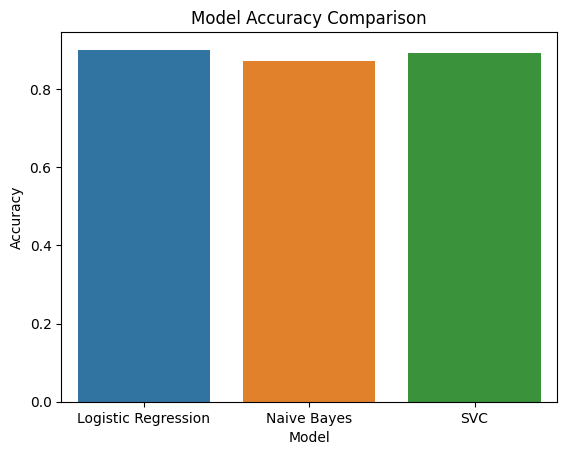

In [54]:
sns.barplot(
    data=results,
    x='Model',
    y='Accuracy',
    hue='Model'
)

plt.title('Model Accuracy Comparison')
plt.xticks(rotation=0)

plt.show()

## Observation
### Word Cloud

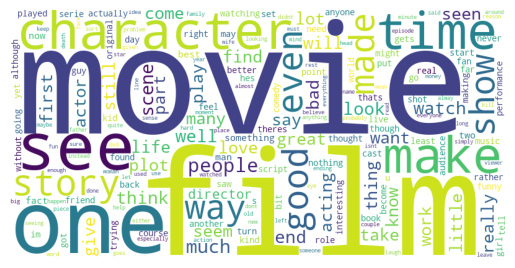

In [55]:
text = " ".join(data['clean_review'])

wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.imshow(wc)
plt.axis('off')
plt.show()

### Most Frequest words

In [56]:
from collections import Counter
words = " ".join(data['clean_review']).split()
Counter(words).most_common(20)

[('the', 645828),
 ('and', 317092),
 ('a', 317050),
 ('of', 286017),
 ('to', 264307),
 ('is', 208622),
 ('in', 181804),
 ('it', 150211),
 ('this', 144341),
 ('i', 144337),
 ('that', 134802),
 ('was', 94395),
 ('as', 89399),
 ('with', 85900),
 ('for', 85505),
 ('movie', 82909),
 ('but', 79703),
 ('film', 73985),
 ('on', 65798),
 ('you', 58639)]

## Model saving

In [57]:
import pickle

pickle.dump(lr, open("lr.pkl", "wb"))
pickle.dump(nb, open("nb.pkl", "wb"))
pickle.dump(svc, open("svc.pkl", "wb"))
pickle.dump(tfidf, open("tfidf.pkl", "wb"))

## Error Analysis

In [58]:
def categorize_error(text):

    categories = []

    text = str(text).lower()
    words = text.split()

    if any(
        word in words
        for word in ['not', 'never', 'no']
    ):
        categories.append('Negation')

    if any(
        word in words
        for word in [
            'but',
            'however',
            'although',
            'though'
        ]
    ):
        categories.append('Mixed Sentiment')

    if len(words) > 100:
        categories.append('Long Context')

    if len(words) < 10:
        categories.append('Short Review')

    if not categories:
        categories.append('Other')

    return ", ".join(categories)

In [59]:
test_indices = y_test.index

X_test_text = data.loc[
    test_indices,
    'review'
]

In [60]:
errors = pd.DataFrame({
    "review": X_test_text,
    "actual": y_test,
    "predicted": y_pred_lr
})

errors = errors[
    errors['actual']
    !=
    errors['predicted']
]

errors.head(20)

,review,actual,predicted
38712,"""National Treasure"" (2004) is a thoroughly mis...",negative,positive
47783,His significant charisma and commanding presen...,negative,positive
40146,A horror movie is being shot and things aren't...,positive,negative
43156,I've been a classic horror fan my entire life....,negative,positive
7270,"I was so excited to finally watch ""Pulse"" afte...",negative,positive
43130,"Chayanne is beautiful enough, Vanessa is beaut...",negative,positive
21005,I waited a while to post a review of this docu...,positive,negative
7959,Jamie Foxx does a fine job of impersonating th...,positive,negative
47307,How could a film dealing with illegal Mexican ...,negative,positive
2322,After reading the other tepid reviews and comm...,positive,negative


In [61]:
errors['error_type'] = errors['review'].apply(
    categorize_error
)

In [62]:
errors['error_type'].value_counts()

error_type
Negation, Mixed Sentiment, Long Context    542
Mixed Sentiment, Long Context              139
Negation, Long Context                     114
Long Context                                69
Mixed Sentiment                             37
Negation, Mixed Sentiment                   28
Negation                                    26
Other                                       26
Name: count, dtype: int64

In [63]:
(
    errors['error_type']
    .value_counts(normalize=True)
    *100
).round(2)

error_type
Negation, Mixed Sentiment, Long Context    55.25
Mixed Sentiment, Long Context              14.17
Negation, Long Context                     11.62
Long Context                                7.03
Mixed Sentiment                             3.77
Negation, Mixed Sentiment                   2.85
Negation                                    2.65
Other                                       2.65
Name: proportion, dtype: float64

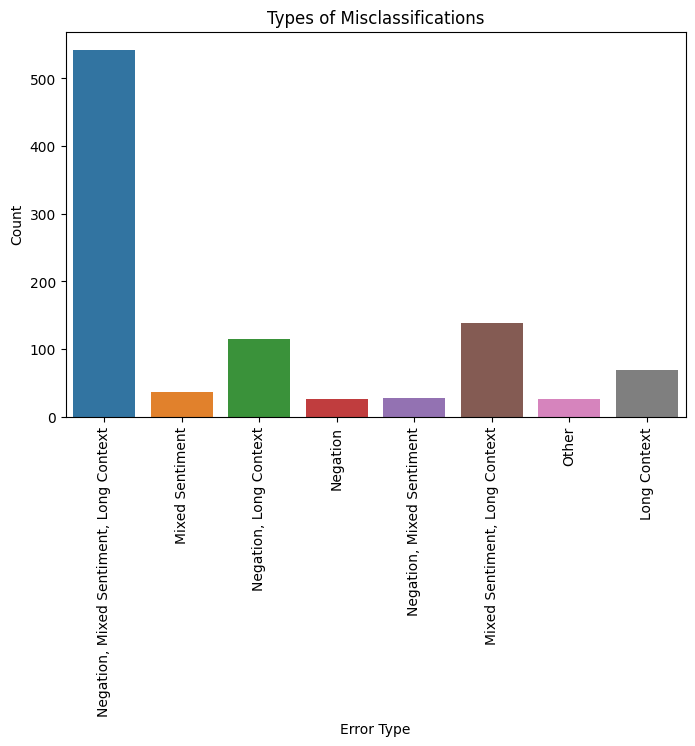

In [64]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=errors,
    x='error_type',
    hue='error_type'
)

plt.title(
    'Types of Misclassifications'
)

plt.xlabel(
    'Error Type'
)

plt.ylabel(
    'Count'
)

plt.xticks(rotation=90)

plt.show()

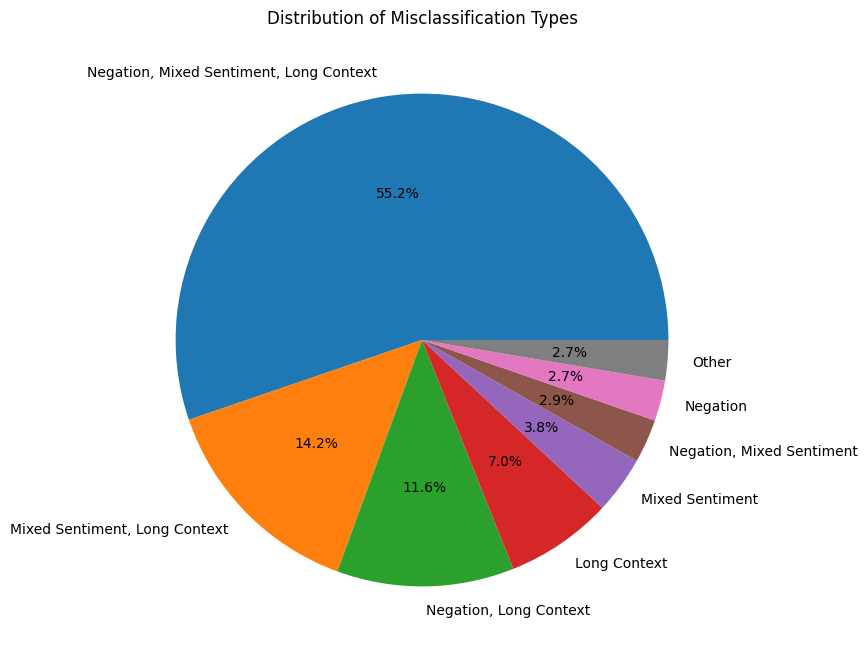

In [65]:
plt.figure(figsize=(8,8))

errors['error_type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title(
    'Distribution of Misclassification Types'
)

plt.show()

## Lime Explainability

In [66]:
def preprocess(text):
    text = clean_text(text)

    tokens = word_tokenize(text)

    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    tokens = [
        lemmatizer.lemmatize(word, pos='v')
        for word in tokens
    ]

    return " ".join(tokens)

In [67]:
from lime.lime_text import LimeTextExplainer

In [68]:
explainer = LimeTextExplainer(
    class_names=['negative', 'positive']
)

In [69]:
def predict_proba(texts):

    processed = [
        preprocess(text)
        for text in texts
    ]

    vectors = tfidf.transform(processed)

    return lr.predict_proba(vectors)

In [70]:
review = "This movie was fantastic and I absolutely loved it."

exp = explainer.explain_instance(
    review,
    predict_proba,
    num_features=10
)

In [71]:
exp.as_list()

[('fantastic', 0.23865262205067253),
 ('loved', 0.18900136116526256),
 ('movie', -0.03398394099110994),
 ('This', 0.016596407506479786),
 ('absolutely', -0.007257793533461914),
 ('was', 0.003934836725449495),
 ('it', 0.002927904235484769),
 ('and', 0.0028657253089442282),
 ('I', -0.0011220825342429701)]

In [72]:
review = "This movie was terrible and boring."

exp = explainer.explain_instance(
    review,
    predict_proba,
    num_features=10
)

exp.as_list()

[('terrible', -0.10469621798694614),
 ('boring', -0.10366266168445497),
 ('movie', -0.04113955824658874),
 ('and', -0.010551733369673483),
 ('was', -0.009207785330183552),
 ('This', -0.004850580319731947)]

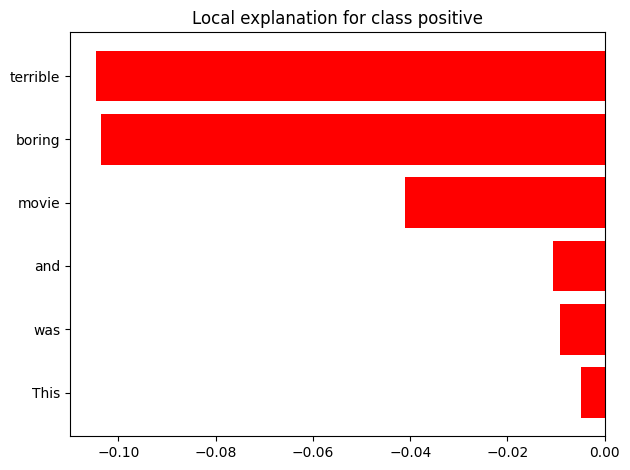

In [73]:
fig = exp.as_pyplot_figure()

plt.tight_layout()
plt.show()

In [74]:
review = errors.iloc[0]['review']

print(review)
print(
    "Actual:",
    errors.iloc[0]['actual']
)
print(
    "Predicted:",
    errors.iloc[0]['predicted']
)

"National Treasure" (2004) is a thoroughly misguided hodge-podge of plot entanglements that borrow from nearly every cloak and dagger government conspiracy cliché that has ever been written. The film stars Nicholas Cage as Benjamin Franklin Gates (how precious is that, I ask you?); a seemingly normal fellow who, for no other reason than being of a lineage of like-minded misguided fortune hunters, decides to steal a 'national treasure' that has been hidden by the United States founding fathers. After a bit of subtext and background that plays laughably (unintentionally) like Indiana Jones meets The Patriot, the film degenerates into one misguided whimsy after another  attempting to create a 'Stanley Goodspeed' regurgitation of Nicholas Cage and launch the whole convoluted mess forward with a series of high octane, but disconnected misadventures.<br /><br />The relevancy and logic to having George Washington and his motley crew of patriots burying a king's ransom someplace on native soi

In [75]:
exp = explainer.explain_instance(
    review,
    predict_proba,
    num_features=15
)

exp.as_list()

[('great', 0.07417945956068697),
 ('brilliant', 0.0581784915902083),
 ('solid', 0.05598454790521255),
 ('mess', -0.05091025836372913),
 ('film', 0.04607365810339714),
 ('delivers', 0.04320988172443816),
 ('attempting', -0.04249424272897111),
 ('also', 0.042230088961184936),
 ('misguided', -0.03846329515359233),
 ('material', -0.036458908539662535),
 ('oh', -0.03590955038909966),
 ('generous', -0.03519380925278494),
 ('t', -0.03454353314352417),
 ('reason', -0.03360667818097307),
 ('Honestly', -0.026415474365177723)]

## Bert Analysis

In [76]:
from transformers import pipeline

bert = pipeline(
    "text-classification",
    model="textattack/bert-base-uncased-imdb"
)

c:\Users\Nandana\OneDrive\Desktop\Strydo_internship\PROJECT\Sentiment analysis\CineInsightAI\.venv\lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.7.0) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(
c:\Users\Nandana\OneDrive\Desktop\Strydo_internship\PROJECT\Sentiment analysis\CineInsightAI\.venv\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [77]:
def bert_predict(text):

    result = bert(
        str(text),
        truncation=True,
        max_length=512
    )[0]

    label_map = {
        "LABEL_0": "negative",
        "LABEL_1": "positive"
    }

    prediction = label_map[
        result["label"]
    ]

    confidence = round(
        result["score"] * 100,
        2
    )

    return prediction, confidence

In [78]:
tests = [
    "I love this movie",
    "I hate this movie",
    "This movie was terrible and boring.",
    "This movie was fantastic and I absolutely loved it.",
    "I hate horror movies but I loved this one."
]

for text in tests:

    sentiment, score = bert_predict(text)

    print("="*70)
    print(text)
    print(
        "BERT:",
        sentiment,
        round(score*100,2),
        "%"
    )

I love this movie
BERT: positive 9929.0 %
I hate this movie
BERT: negative 9949.0 %
This movie was terrible and boring.
BERT: negative 9996.0 %
This movie was fantastic and I absolutely loved it.
BERT: positive 9855.0 %
I hate horror movies but I loved this one.
BERT: positive 9959.0 %


In [79]:
comparison = []

for text in tests:

    lr_pred = lr.predict(
        tfidf.transform(
            [preprocess(text)]
        )
    )[0]

    bert_pred, score = bert_predict(text)

    comparison.append({
        "Review": text,
        "LR": lr_pred,
        "BERT": bert_pred,
        "Confidence": round(score*100,2)
    })

comparison_df = pd.DataFrame(comparison)
comparison_df

,Review,LR,BERT,Confidence
0,I love this movie,positive,positive,9929.0
1,I hate this movie,negative,negative,9949.0
2,This movie was terrible and boring.,negative,negative,9996.0
3,This movie was fantastic and I absolutely love...,positive,positive,9855.0
4,I hate horror movies but I loved this one.,positive,positive,9959.0


In [80]:
review = errors.iloc[0]['review']

print("Actual:",
      errors.iloc[0]['actual'])

print("LR:",
      errors.iloc[0]['predicted'])

print(
    "BERT:",
    bert_predict(review)
)

Actual: negative
LR: positive
BERT: ('negative', 99.98)


In [81]:
comparison_final = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'IMDb BERT'
    ],
    'Handles Negation': [
        'Limited',
        'Excellent'
    ],
    'Handles Long Context': [
        'Poor',
        'Excellent'
    ],
    'Handles Mixed Sentiment': [
        'Poor',
        'Good'
    ],
    'Explainability': [
        'High',
        'Medium'
    ],
    'Inference Speed': [
        'Fast',
        'Slow'
    ]
})

comparison_final

,Model,Handles Negation,Handles Long Context,Handles Mixed Sentiment,Explainability,Inference Speed
0,Logistic Regression,Limited,Poor,Poor,High,Fast
1,IMDb BERT,Excellent,Excellent,Good,Medium,Slow


## Emotion Detection using Transformers

In [82]:
emotion_model = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=None
)

c:\Users\Nandana\OneDrive\Desktop\Strydo_internship\PROJECT\Sentiment analysis\CineInsightAI\.venv\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [83]:
def detect_emotion(text):

    result = emotion_model(
        text[:512]
    )[0]

    emotion = max(
        result,
        key=lambda x: x["score"]
    )

    return emotion["label"]

In [84]:
reviews = [
    "The ending made me cry.",
    "I loved every minute of this movie.",
    "This movie made me angry."
]

for review in reviews:
    print(
        review,
        "->",
        detect_emotion(review)
    )

The ending made me cry. -> sadness
I loved every minute of this movie. -> joy
This movie made me angry. -> anger


## Aspect-Based Sentiment Analysis

In [85]:
aspects = {
    "Acting": [
        "acting",
        "actor",
        "performance"
    ],
    "Story": [
        "story",
        "plot",
        "screenplay"
    ],
    "Music": [
        "music",
        "soundtrack"
    ],
    "Ending": [
        "ending",
        "climax"
    ],
    "Visuals": [
        "visuals",
        "cinematography"
    ]
}

In [86]:
def aspect_analysis(review):

    result = {}

    sentences = review.split(".")

    label_map = {
        "LABEL_0": "negative",
        "LABEL_1": "positive"
    }

    for aspect, keywords in aspects.items():

        result[aspect] = "Not Mentioned"

        for sentence in sentences:

            if any(
                keyword in sentence.lower()
                for keyword in keywords
            ):

                pred = bert(
                    sentence,
                    truncation=True
                )[0]["label"]

                result[aspect] = label_map[pred]

                break

    return result

In [87]:
review = """
The acting was fantastic
but the ending was terrible.
"""

aspect_analysis(review)

{'Acting': 'negative',
 'Story': 'Not Mentioned',
 'Music': 'Not Mentioned',
 'Ending': 'negative',
 'Visuals': 'Not Mentioned'}

## Conclusion

Classical machine learning models such as Logistic Regression achieved strong performance (88.7% accuracy) and offered excellent interpretability and computational efficiency. However, error analysis revealed significant limitations when dealing with long contextual reviews and mixed sentiments.

Transformer-based models such as BERT demonstrated superior contextual understanding and successfully corrected several misclassifications made by Logistic Regression, particularly in long and complex reviews. This highlights the importance of contextual embeddings in modern NLP applications.